In [2]:
import torch
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

X = housing['data']
y = housing['target']

X_train_full, X_test, y_train_full, y_test = train_test_split(X,y)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full,y_train_full)

print(X_train.shape, X_test.shape, X_valid.shape)

scl = StandardScaler()
scl.fit(X_train)

X_train = scl.transform(X_train)
X_test = scl.transform(X_test)
X_valid = scl.transform(X_valid)

X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
X_valid = torch.FloatTensor(X_valid)

y_train = torch.FloatTensor(y_train).view(-1,1)
y_test = torch.FloatTensor(y_test).view(-1,1)
y_valid = torch.FloatTensor(y_valid).view(-1,1)

# y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
# y_test = torch.tensor(y_test, dtype=torch.float32).view(-1,1)
# y_valid = torch.tensor(y_valid, dtype=torch.float32).view(-1,1)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
valid_dataset = TensorDataset(X_valid, y_valid)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)
valid_loader = DataLoader(valid_dataset, batch_size=32)

(11610, 8) (5160, 8) (3870, 8)


In [4]:
import torch.nn as nn
import torchmetrics
import matplotlib.pyplot as plt
import numpy as np

In [5]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'cpu'

In [45]:
def train(model, optimizer, criterion, metric, train_loader, valid_loader, n_epochs):
	history = {
		'loss' : [],
		'train_metric' : [],
		'valid_metric' : [],
	}
	best_metric = float('inf')
	best_model_weights = None
	best_epoch = None

	for epoch in range(n_epochs):
		# Training 
		total_loss = 0
		metric.reset()
		for X_batch, y_batch in train_loader:
			X_batch, y_batch = X_batch.to(device), y_batch.to(device)
			model.train()
			y_pred = model(X_batch)
			loss = criterion(y_pred, y_batch)
			total_loss += loss.item()
			loss.backward()
			optimizer.step()
			optimizer.zero_grad()
			metric.update(y_pred, y_batch)
		
		avg_loss = total_loss / len(train_loader)
		history['loss'].append(avg_loss)

		avg_metric_train = metric.compute().item()
		history['train_metric'].append(avg_metric_train)

		# Evaluation 
		model.eval()
		metric.reset()
		with torch.no_grad():
			for X_batch, y_batch in valid_loader:
				X_batch, y_batch = X_batch.to(device), y_batch.to(device)
				y_pred = model(X_batch)
				metric.update(y_pred, y_batch)

		avg_metric_valid = metric.compute().item()
		history['valid_metric'].append(avg_metric_valid)

		# Log
		print(
			f'Epoch: {epoch+1}/{n_epochs}, '
			+f'Loss: {round(avg_loss,3)}, '
			+f'Train Metric: {round(avg_metric_train,3)}, ' 
			+f'Valid Metric: {round(avg_metric_valid,3)}'
		)

		# Checkpoint
		if avg_metric_valid < best_metric:
			best_metric = avg_metric_valid
			import copy
			best_model_weights = copy.deepcopy(model.state_dict())
			best_epoch = epoch + 1
			print(f'---Best Valid Metric: {round(best_metric,3)}')

	if best_model_weights:
		model.load_state_dict(best_model_weights)

	return history

def plot_history(history, n_epochs, metric):
    plt.plot(np.arange(n_epochs) + 1, history['train_metric'], linestyle='--', color='r', marker='.', label='Train')
    plt.plot(np.arange(n_epochs) + 1, history['valid_metric'], linestyle='--', color='b', marker='.', label='Valid')
    plt.legend()
    plt.grid()
    plt.xlabel('Epochs')
    plt.ylabel(f'{metric.__class__.__name__}')
    plt.show()

Epoch: 1/20, Loss: 0.883, Train Metric: 0.675, Valid Metric: 0.558
---Best Valid Metric: 0.558
Epoch: 2/20, Loss: 0.524, Train Metric: 0.528, Valid Metric: 0.517
---Best Valid Metric: 0.517
Epoch: 3/20, Loss: 0.474, Train Metric: 0.497, Valid Metric: 0.503
---Best Valid Metric: 0.503
Epoch: 4/20, Loss: 0.446, Train Metric: 0.479, Valid Metric: 0.487
---Best Valid Metric: 0.487
Epoch: 5/20, Loss: 0.43, Train Metric: 0.467, Valid Metric: 0.49
Epoch: 6/20, Loss: 0.415, Train Metric: 0.458, Valid Metric: 0.467
---Best Valid Metric: 0.467
Epoch: 7/20, Loss: 0.404, Train Metric: 0.451, Valid Metric: 0.458
---Best Valid Metric: 0.458
Epoch: 8/20, Loss: 0.394, Train Metric: 0.444, Valid Metric: 0.45
---Best Valid Metric: 0.45
Epoch: 9/20, Loss: 0.385, Train Metric: 0.438, Valid Metric: 0.449
---Best Valid Metric: 0.449
Epoch: 10/20, Loss: 0.377, Train Metric: 0.434, Valid Metric: 0.438
---Best Valid Metric: 0.438
Epoch: 11/20, Loss: 0.371, Train Metric: 0.43, Valid Metric: 0.433
---Best Valid 

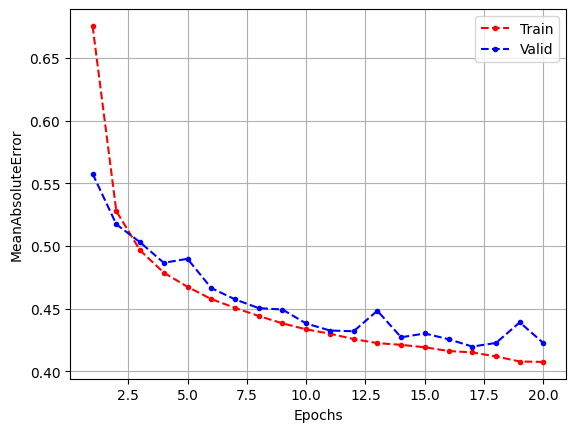

In [46]:
learning_rate = 0.01
n_epochs=20


class PriceRegressor(nn.Module):
	def __init__(self, n_features, n_hidden1, n_hidden2):
		super().__init__()
		self.stack = nn.Sequential(
			nn.Linear(in_features=n_features, out_features=n_hidden1), 
			nn.LeakyReLU(),
			nn.Linear(in_features=n_hidden1, out_features=n_hidden2), 
			nn.LeakyReLU(),
			nn.Linear(in_features=n_hidden2, out_features=1)
		)
        
	def forward(self, X):
		y = self.stack(X)
		return y

model = PriceRegressor(
	n_features=8, 
	n_hidden1 = 30,
	n_hidden2 = 50,
	).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate)
metric = torchmetrics.MeanAbsoluteError().to(device)

history = train(model, optimizer, criterion, metric, train_loader, valid_loader, n_epochs)
plot_history(history, n_epochs, metric)

# tuning

In [31]:
import optuna

sampler = optuna.samplers.TPESampler()
study = optuna.create_study(direction='minimize', sampler=sampler)

# study.optimize(objective, n_trials=5)

[I 2026-04-17 16:23:09,121] A new study created in memory with name: no-name-f011ac85-6e27-4f29-afd4-1289e21e5f74


In [ ]:
def objective(trial: optuna.Trial):
	# parameters
	learning_rate = trial.suggest_float("learning_rate", 0.00001, 0.1, log=True)
	momentum = trial.suggest_float("momentum", 0., 1.)
	n_hidden = trial.suggest_int("n_hidden", 10, 500)
	# arch = trial.suggest_categorical("arch", ["normal", "residual", "aux"])
    
	# setup
	model = PriceRegressor(
	n_features=8, 
	n_hidden1 = n_hidden,
	n_hidden2 = n_hidden,
	).to(device)

	criterion = nn.MSELoss()
	optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate, momentum=momentum)
	metric = torchmetrics.MeanAbsoluteError().to(device)

	# train
	history = train(model, optimizer, criterion, metric, train_loader, valid_loader, n_epochs=20)
	valid_metric = min(history['valid_metric'])

	return valid_metric

study.optimize(objective, n_trials=5)

Epoch: 1/20, Loss: 0.989, Train Metric: 0.679, Valid Metric: 0.562
Epoch: 2/20, Loss: 0.552, Train Metric: 0.525, Valid Metric: 0.503
Epoch: 3/20, Loss: 0.465, Train Metric: 0.491, Valid Metric: 0.478
Epoch: 4/20, Loss: 0.433, Train Metric: 0.469, Valid Metric: 0.465
Epoch: 5/20, Loss: 0.429, Train Metric: 0.46, Valid Metric: 0.463
Epoch: 6/20, Loss: 0.407, Train Metric: 0.452, Valid Metric: 0.46
Epoch: 7/20, Loss: 0.393, Train Metric: 0.446, Valid Metric: 0.445
Epoch: 8/20, Loss: 0.38, Train Metric: 0.437, Valid Metric: 0.442
Epoch: 9/20, Loss: 0.372, Train Metric: 0.432, Valid Metric: 0.436
Epoch: 10/20, Loss: 0.365, Train Metric: 0.427, Valid Metric: 0.438
Epoch: 11/20, Loss: 0.36, Train Metric: 0.425, Valid Metric: 0.43
Epoch: 12/20, Loss: 0.353, Train Metric: 0.421, Valid Metric: 0.427
Epoch: 13/20, Loss: 0.349, Train Metric: 0.417, Valid Metric: 0.421
Epoch: 14/20, Loss: 0.344, Train Metric: 0.415, Valid Metric: 0.42
Epoch: 15/20, Loss: 0.341, Train Metric: 0.412, Valid Metric: 0

[I 2026-04-17 16:23:22,441] Trial 0 finished with value: 0.40497398376464844 and parameters: {'learning_rate': 0.005720335638821497, 'momentum': 0.4899085448570063, 'n_hidden': 35}. Best is trial 0 with value: 0.40497398376464844.


Epoch: 20/20, Loss: 0.326, Train Metric: 0.4, Valid Metric: 0.409
Epoch: 1/20, Loss: 0.575, Train Metric: 0.535, Valid Metric: 0.483
Epoch: 2/20, Loss: nan, Train Metric: nan, Valid Metric: nan
Epoch: 3/20, Loss: nan, Train Metric: nan, Valid Metric: nan
Epoch: 4/20, Loss: nan, Train Metric: nan, Valid Metric: nan
Epoch: 5/20, Loss: nan, Train Metric: nan, Valid Metric: nan
Epoch: 6/20, Loss: nan, Train Metric: nan, Valid Metric: nan
Epoch: 7/20, Loss: nan, Train Metric: nan, Valid Metric: nan
Epoch: 8/20, Loss: nan, Train Metric: nan, Valid Metric: nan
Epoch: 9/20, Loss: nan, Train Metric: nan, Valid Metric: nan
Epoch: 10/20, Loss: nan, Train Metric: nan, Valid Metric: nan
Epoch: 11/20, Loss: nan, Train Metric: nan, Valid Metric: nan
Epoch: 12/20, Loss: nan, Train Metric: nan, Valid Metric: nan
Epoch: 13/20, Loss: nan, Train Metric: nan, Valid Metric: nan
Epoch: 14/20, Loss: nan, Train Metric: nan, Valid Metric: nan
Epoch: 15/20, Loss: nan, Train Metric: nan, Valid Metric: nan
Epoch: 

[I 2026-04-17 16:23:54,997] Trial 1 finished with value: 0.4826250374317169 and parameters: {'learning_rate': 0.04870858363777389, 'momentum': 0.3401545954205788, 'n_hidden': 273}. Best is trial 0 with value: 0.40497398376464844.


Epoch: 20/20, Loss: nan, Train Metric: nan, Valid Metric: nan
Epoch: 1/20, Loss: 3.811, Train Metric: 1.581, Valid Metric: 1.15
Epoch: 2/20, Loss: 1.703, Train Metric: 0.913, Valid Metric: 0.82
Epoch: 3/20, Loss: 1.124, Train Metric: 0.741, Valid Metric: 0.722
Epoch: 4/20, Loss: 0.892, Train Metric: 0.68, Valid Metric: 0.679
Epoch: 5/20, Loss: 0.783, Train Metric: 0.648, Valid Metric: 0.654
Epoch: 6/20, Loss: 0.726, Train Metric: 0.628, Valid Metric: 0.638
Epoch: 7/20, Loss: 0.695, Train Metric: 0.615, Valid Metric: 0.626
Epoch: 8/20, Loss: 0.675, Train Metric: 0.605, Valid Metric: 0.617
Epoch: 9/20, Loss: 0.661, Train Metric: 0.596, Valid Metric: 0.611
Epoch: 10/20, Loss: 0.65, Train Metric: 0.59, Valid Metric: 0.605
Epoch: 11/20, Loss: 0.641, Train Metric: 0.585, Valid Metric: 0.6
Epoch: 12/20, Loss: 0.632, Train Metric: 0.58, Valid Metric: 0.595
Epoch: 13/20, Loss: 0.624, Train Metric: 0.575, Valid Metric: 0.592
Epoch: 14/20, Loss: 0.617, Train Metric: 0.572, Valid Metric: 0.588
Epo

...

Epoch: 20/20, Loss: 0.581, Train Metric: 0.552, Valid Metric: 0.568
Epoch: 1/20, Loss: 3.969, Train Metric: 1.64, Valid Metric: 1.322
Epoch: 2/20, Loss: 2.254, Train Metric: 1.099, Valid Metric: 0.971
Epoch: 3/20, Loss: 1.636, Train Metric: 0.881, Valid Metric: 0.848
Epoch: 4/20, Loss: 1.324, Train Metric: 0.798, Valid Metric: 0.78
Epoch: 5/20, Loss: 1.127, Train Metric: 0.745, Valid Metric: 0.741
Epoch: 6/20, Loss: 0.984, Train Metric: 0.708, Valid Metric: 0.708
Epoch: 7/20, Loss: 0.882, Train Metric: 0.679, Valid Metric: 0.682
Epoch: 8/20, Loss: 0.812, Train Metric: 0.659, Valid Metric: 0.662
Epoch: 9/20, Loss: 0.764, Train Metric: 0.64, Valid Metric: 0.647
Epoch: 10/20, Loss: 0.729, Train Metric: 0.627, Valid Metric: 0.636
Epoch: 11/20, Loss: 0.706, Train Metric: 0.617, Valid Metric: 0.627
Epoch: 12/20, Loss: 0.689, Train Metric: 0.608, Valid Metric: 0.619
Epoch: 13/20, Loss: 0.676, Train Metric: 0.601, Valid Metric: 0.613
Epoch: 14/20, Loss: 0.665, Train Metric: 0.596, Valid Metric

[I 2026-04-17 16:25:11,131] Trial 3 finished with value: 0.58730548620224 and parameters: {'learning_rate': 6.283265360994867e-05, 'momentum': 0.10627952098174054, 'n_hidden': 405}. Best is trial 0 with value: 0.40497398376464844.


Epoch: 20/20, Loss: 0.628, Train Metric: 0.574, Valid Metric: 0.587
Epoch: 1/20, Loss: 1.811, Train Metric: 0.907, Valid Metric: 0.634
Epoch: 2/20, Loss: 0.737, Train Metric: 0.606, Valid Metric: 0.593
Epoch: 3/20, Loss: 0.619, Train Metric: 0.562, Valid Metric: 0.562
Epoch: 4/20, Loss: 0.557, Train Metric: 0.539, Valid Metric: 0.55
Epoch: 5/20, Loss: 0.521, Train Metric: 0.52, Valid Metric: 0.531
Epoch: 6/20, Loss: 0.496, Train Metric: 0.508, Valid Metric: 0.513
Epoch: 7/20, Loss: 0.477, Train Metric: 0.499, Valid Metric: 0.502
Epoch: 8/20, Loss: 0.465, Train Metric: 0.49, Valid Metric: 0.5
Epoch: 9/20, Loss: 0.457, Train Metric: 0.486, Valid Metric: 0.488
Epoch: 10/20, Loss: 0.442, Train Metric: 0.477, Valid Metric: 0.485
Epoch: 11/20, Loss: 0.435, Train Metric: 0.473, Valid Metric: 0.478
Epoch: 12/20, Loss: 0.432, Train Metric: 0.47, Valid Metric: 0.474
Epoch: 13/20, Loss: 0.425, Train Metric: 0.465, Valid Metric: 0.471
Epoch: 14/20, Loss: 0.417, Train Metric: 0.46, Valid Metric: 0.

[I 2026-04-17 16:25:51,148] Trial 4 finished with value: 0.4518758952617645 and parameters: {'learning_rate': 5.987274250052841e-05, 'momentum': 0.944310881080005, 'n_hidden': 471}. Best is trial 0 with value: 0.40497398376464844.


Epoch: 20/20, Loss: 0.394, Train Metric: 0.445, Valid Metric: 0.452


In [33]:
study.best_params

{'learning_rate': 0.005720335638821497,
 'momentum': 0.4899085448570063,
 'n_hidden': 35}

In [34]:
study.best_value

0.40497398376464844

# final training

Epoch: 1/40, Loss: 0.792, Train Metric: 0.636, Valid Metric: 0.552
---Best Valid Metric: 0.552
Epoch: 2/40, Loss: 0.503, Train Metric: 0.512, Valid Metric: 0.498
---Best Valid Metric: 0.498
Epoch: 3/40, Loss: 0.456, Train Metric: 0.483, Valid Metric: 0.482
---Best Valid Metric: 0.482
Epoch: 4/40, Loss: 0.43, Train Metric: 0.467, Valid Metric: 0.467
---Best Valid Metric: 0.467
Epoch: 5/40, Loss: 0.415, Train Metric: 0.457, Valid Metric: 0.474
Epoch: 6/40, Loss: 0.405, Train Metric: 0.451, Valid Metric: 0.452
---Best Valid Metric: 0.452
Epoch: 7/40, Loss: 0.394, Train Metric: 0.443, Valid Metric: 0.453
Epoch: 8/40, Loss: 0.387, Train Metric: 0.439, Valid Metric: 0.443
---Best Valid Metric: 0.443
Epoch: 9/40, Loss: 0.378, Train Metric: 0.434, Valid Metric: 0.451
Epoch: 10/40, Loss: 0.372, Train Metric: 0.431, Valid Metric: 0.437
---Best Valid Metric: 0.437
Epoch: 11/40, Loss: 0.367, Train Metric: 0.428, Valid Metric: 0.433
---Best Valid Metric: 0.433
Epoch: 12/40, Loss: 0.362, Train Metri

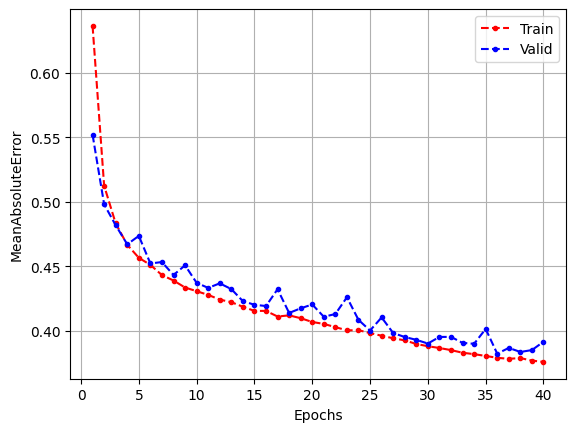

In [47]:
model = PriceRegressor(
	n_features=8, 
	n_hidden1 = study.best_params['n_hidden'],
	n_hidden2 = study.best_params['n_hidden'],
	).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(
    params=model.parameters(), 
    lr=study.best_params['learning_rate'], 
    momentum=study.best_params['momentum'], 
    )
metric = torchmetrics.MeanAbsoluteError().to(device)

n_epochs=40
history = train(
    model, 
	optimizer, 
	criterion, 
	metric, 
	train_loader, 
	valid_loader, 
	n_epochs
)
plot_history(history, n_epochs, metric)

# testing

In [48]:
model.eval()
metric.reset()
# with torch.no_grad():
with torch.inference_mode():
	for X_batch, y_batch in test_loader:
		X_batch, y_batch = X_batch.to(device), y_batch.to(device)
		y_pred = model(X_batch)
		metric.update(y_pred, y_batch)
avg_metric_test = metric.compute().item()
print(f'Test Metric: {round(avg_metric_test,3)}')

Test Metric: 0.38


In [49]:
model.eval()

X_new, y_new = next(iter(test_loader))
X_new, y_new = X_new.to(device), y_new.to(device)

with torch.inference_mode():
	y_pred = model(X_new)

y_pred[:5]

tensor([[1.2149],
        [2.1556],
        [2.8255],
        [3.3664],
        [2.9382]])

In [50]:
sum([param.numel() for param in model.parameters()])

1611

# saving

## structure + weights

In [ ]:
torch.save(model, "fashion_mnist_model.pt")

loaded_model = torch.load("my_fashion_mnist.pt", weights_only=False)

## weights only

In [53]:
model_data = {
    "model_state_dict": model.state_dict(),
    "model_hyperparameters": {
        "n_features": 8,
        "n_hidden1": study.best_params['n_hidden'],
        "n_hidden2": study.best_params['n_hidden'],
    }
}
torch.save(model_data, "fashion_mnist_model.pt")

loaded_data = torch.load("fashion_mnist_model.pt", weights_only=True)
new_model = PriceRegressor(**loaded_data["model_hyperparameters"])
new_model.load_state_dict(loaded_data["model_state_dict"])
new_model

PriceRegressor(
  (stack): Sequential(
    (0): Linear(in_features=8, out_features=35, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=35, out_features=35, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=35, out_features=1, bias=True)
  )
)